In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [ ]:
df = pd.read_csv('../data/personal_carbon_footprint_behavior.csv')

**Questions This Notebook Explores**

- Which types of behaviors contribute most to carbon footprint?
- Can users be grouped and provide insight for predictive modeling?
- Are eco-friendly actions beneficial in lowering a user's footprint?
- Does renewable energy usage reduce emissions?

In [50]:
df.head()

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium


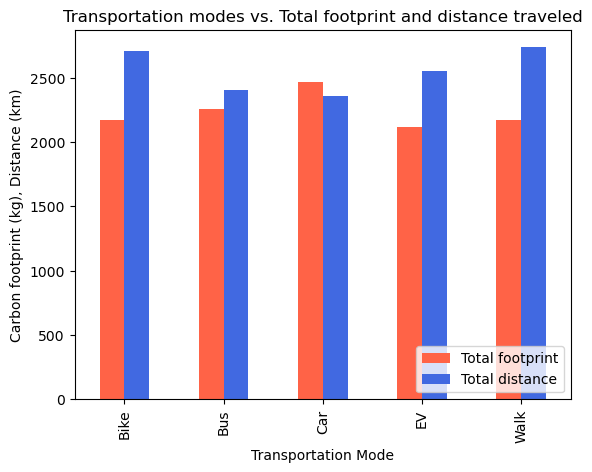

                Efficiency (km/kg)
transport_mode                    
Bike                      1.245398
Bus                       1.066134
Car                       0.954705
EV                        1.207565
Walk                      1.261644


In [51]:
action = pd.DataFrame(df.groupby('transport_mode')['carbon_footprint_kg'].sum())
distance = pd.DataFrame(df.groupby('transport_mode')['distance_km'].sum())

combined = pd.concat([action, distance], axis=1)
combined_ren = combined.rename(columns={'distance_km': 'Total distance', 'carbon_footprint_kg': 'Total footprint'})
combined_ren['Efficiency (km/kg)'] = combined_ren['Total distance']/combined_ren['Total footprint']

combined_ren[['Total footprint', 'Total distance']].plot.bar(color=['tomato', 'royalblue'])

plt.xlabel('Transportation Mode')
plt.ylabel('Carbon footprint (kg), Distance (km)')
plt.title('Transportation modes vs. Total footprint and distance traveled')
plt.legend(loc='lower right')
plt.show()

print(combined_ren[['Efficiency (km/kg)']])

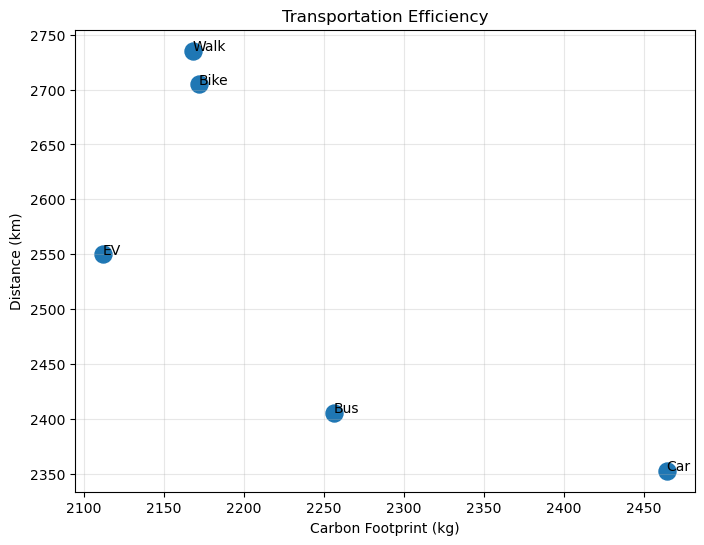

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(combined['carbon_footprint_kg'],combined['distance_km'],s=150)

for mode in combined.index:
    plt.text(combined.loc[mode,'carbon_footprint_kg'],combined.loc[mode,'distance_km'],mode,fontsize=10)

plt.xlabel("Carbon Footprint (kg)")
plt.ylabel("Distance (km)")
plt.title("Transportation Efficiency")

plt.grid(alpha=0.3)
plt.show()

Transportation Mode Efficiency

Both of these visualizations compare transportation methods using total carbon emissions and travel distance.  **Why this matters:** Together they illustrate which transportation model has the greatest environmental impact. The scatter model  puts into perspective the unique distance versus carbon values as they relate to one another, while the bar chart illustrates how each individual mode performs.

In [53]:
radial = df.groupby('carbon_impact_level')[['distance_km', 'electricity_kwh','screen_time_hours','waste_generated_kg','eco_actions']].mean()
radial


,distance_km,electricity_kwh,screen_time_hours,waste_generated_kg,eco_actions
carbon_impact_level,,,,,
High,10.249639,7.717526,5.341237,0.802526,0.912371
Low,8.747389,4.893858,5.613056,0.635193,1.379822
Medium,8.989873,5.967307,5.526697,0.707399,1.104718


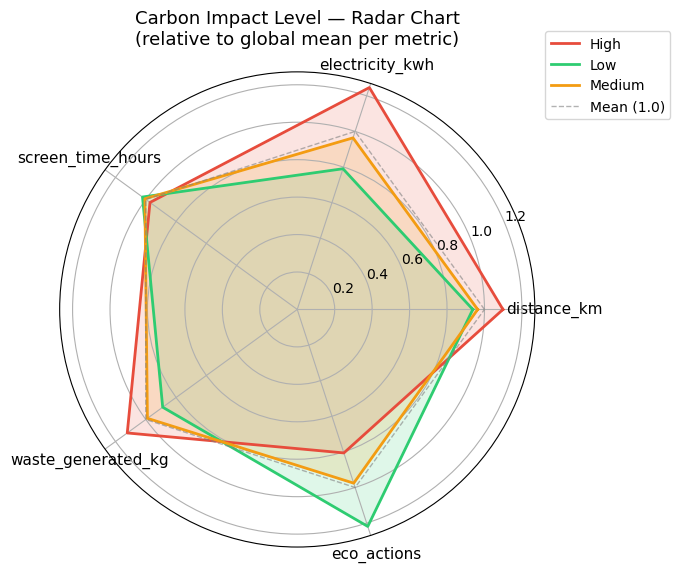

In [54]:

categories = ['distance_km', 'electricity_kwh', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']
data = {
    'High':   [10.249639, 7.717526, 5.341237, 0.802526, 0.912371],
    'Low':    [8.747389,  4.893858, 5.613056, 0.635193, 1.379822],
    'Medium': [8.989873,  5.967307, 5.526697, 0.707399, 1.104718],
}

arr = np.array(list(data.values()))
col_mean = arr.mean(axis=0)
norm = {k: np.array(v) / col_mean for k, v in data.items()}

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors = {'High': '#e74c3c', 'Low': '#2ecc71', 'Medium': '#f39c12'}

for label, values in norm.items():
    v = values.tolist() + values[:1].tolist()
    ax.plot(angles, v, color=colors[label], linewidth=2, label=label)
    ax.fill(angles, v, color=colors[label], alpha=0.15)

ax.plot(angles, [1.0] * len(angles), color='grey', linewidth=1, linestyle='--', alpha=0.6, label='Mean (1.0)')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_title('Carbon Impact Level — Radar Chart\n(relative to global mean per metric)',size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('radar_chart_v2.png', dpi=150, bbox_inches='tight')
plt.show()

Carbon Impact Radar
This radar displays behavioral actions in the form of carbon impact level.

Findings
Users with "High" levels use more electricity, generate the most waste, and travel the furthest while completing the fewest eco-friendly actions. Users with a "Low" impact level are more sustainable, generating the least amount of waste and partaking in more eco-friendly actions. Users classified as "Medium" contribute somewhere in between "Low" and "High" users. **Why this matters:** This chart shows us that carbon footprint is influenced by multiple lifestyles rather than just one variable.

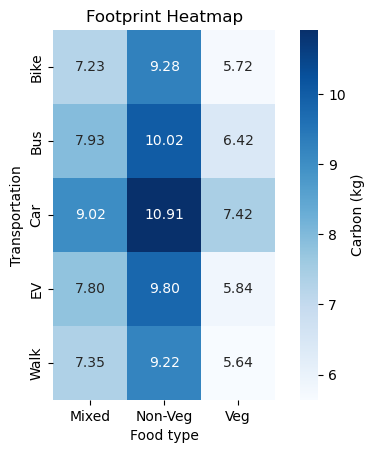

In [55]:
pivot = df.pivot_table(values='carbon_footprint_kg', index='transport_mode', columns='food_type', aggfunc='mean')

#fig, ax = plt.subplots(figsize=(8,8))

sns.heatmap(pivot, annot=True, cmap='Blues', fmt='.2f', square=True, cbar_kws={'label': 'Carbon (kg)'})
plt.title("Footprint Heatmap")
plt.ylabel('Transportation')
plt.xlabel('Food type')
plt.show()

Relationships Between Transportation and Eating Habits

Between each transportation category, users who consume non-vegetarian diets displayed higher average carbon footprints than other diets. Most notibly, those who consume vegetarian diets had a much lower average footprint. **Why this matters:** This suggests that dietary habits contribute to additional environmental impacts independent of transporation choice.

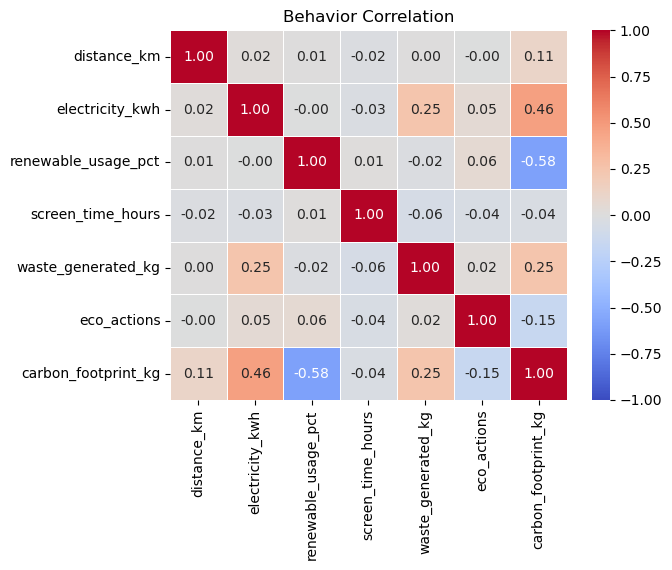

In [56]:
df_numbers = df[['distance_km', 'electricity_kwh', 'renewable_usage_pct', 'screen_time_hours', 'waste_generated_kg', 'eco_actions', 'carbon_footprint_kg']]
df_corr = df_numbers.corr()
#df_numbers
#print(df_corr)
sns.heatmap(df_corr, annot=True, vmin=-1, vmax=1,cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Behavior Correlation")
plt.show()

Relationships Between Lifestyle Variables

The correlation matrix identified which behaviors tend to occur together. Strong positive correlations may include bahvaiors that when paired, contirbute to higher emissions.

Commonly, electrical usage and waste generated have an increase correlation to carbon impact. Renerable energy usage has a moderatly negative correlation with carbon footprint, and electrical usage has a moderately positive correlation.

These correlations, however, imply relationships that should be investigated further before drawing definitive conclusions with.

**Why this matters:** The notibly scored correlations above should be the focus of work in later sections of the notebook, as their possible relation here is moderately possible.

<Axes: >

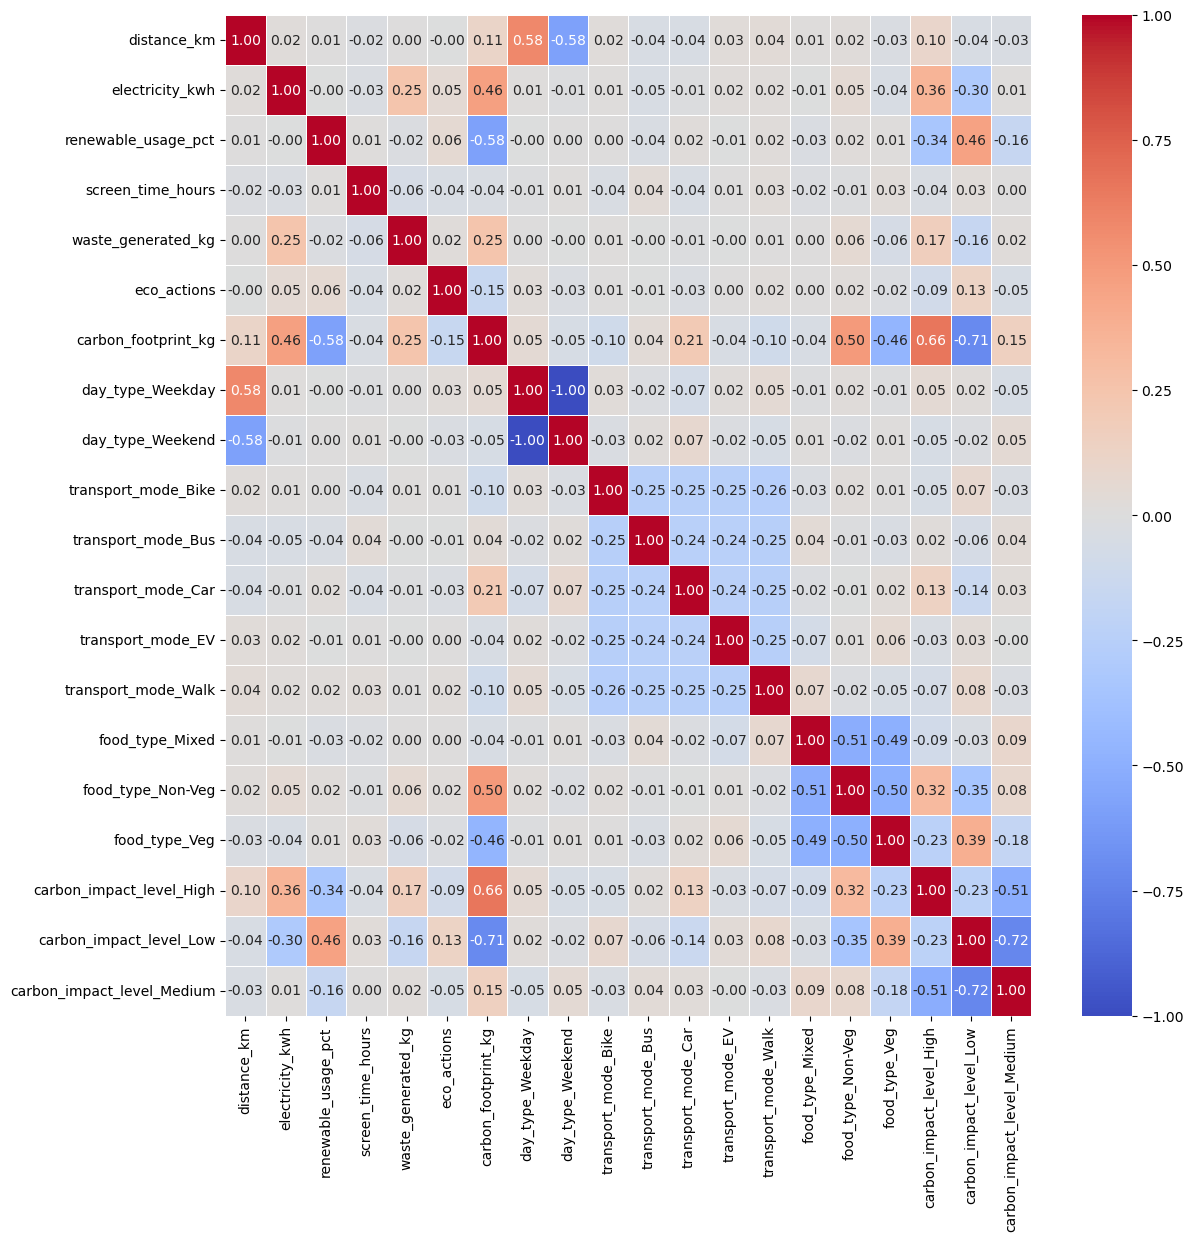

In [57]:
df_dummies = df.copy()
df_dummies = df_dummies.drop(columns=('user_id'))

df_dummies = pd.get_dummies(df_dummies, dtype=int)

plt.figure(figsize=(13,13))

df_corr2 = df_dummies.corr()
sns.heatmap(df_corr2, annot=True, vmin=-1, vmax=1,cmap="coolwarm", fmt=".2f", linewidths=0.5)

#df_dummies

The above model shows the correlation with each behavior in the dataset. This is simply if you are curious as to how they interact and corroborate other discoveries above.

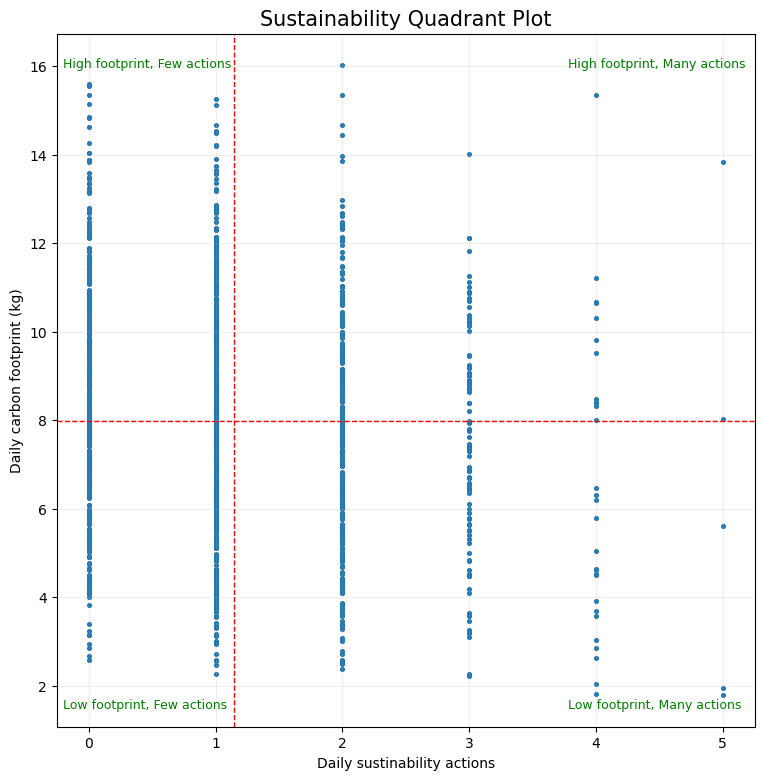

In [58]:
x_mid = np.mean(df['eco_actions'])
y_mid = np.mean(df['carbon_footprint_kg'])

fig, ax = plt.subplots(figsize=(9,9))

scatter_plot = ax.scatter(df['eco_actions'], df['carbon_footprint_kg'], s=7)

ax.axvline(x=x_mid, color='red', linestyle='--', linewidth=1)
ax.axhline(y=y_mid, color='red', linestyle='--', linewidth=1)

ax.text(-0.2,y_mid*2,"High footprint, Few actions", fontsize=9, color='green')
ax.text(-0.2,1.5,"Low footprint, Few actions", fontsize=9, color='green')
ax.text(x_mid*3.3,1.5,"Low footprint, Many actions", fontsize=9, color='green')
ax.text(x_mid*3.3,2*y_mid,"High footprint, Many actions", fontsize=9, color='green')

plt.title('Sustainability Quadrant Plot', fontsize=15)
plt.xlabel('Daily sustinability actions')
plt.ylabel('Daily carbon footprint (kg)')
plt.grid(alpha=0.2)
plt.show()

Sustainability Quadrant Graph

This visualization categorizes users into four behavioral groups based on their daily eco-actions and carbon footprint. The results show that fewer people contribute to sustainable actions around two. There does show a decreasing trend of carbon footprint based on increasing sustaiable actions, but this speicific dataset does not have enough data to draw strong conclusions. **Why this matters:** The quadrants provide a simple way to identify users who could benefit most from recommended actions to improve their footprint.

Based on these results, it appears that users infrequently perform more than two eco-friendly actions per day. Do these actions really mean anything anyway?

Average carbon footprint decreases by 0.44 kg for every additional eco-action
R-squared: 0.96


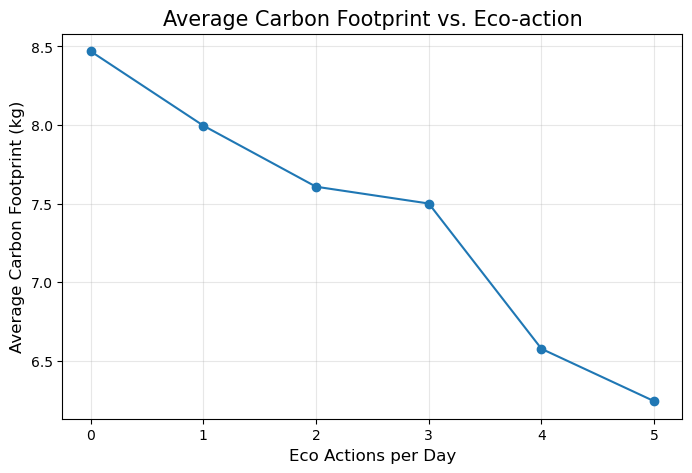

In [102]:
impact = df.groupby('eco_actions')[['carbon_footprint_kg']].mean()

slope, intercept, r_value, p_value, std_error = linregress(impact.index, impact['carbon_footprint_kg'])

plt.figure(figsize=(8,5))
plt.plot(impact, marker='o')

plt.title('Average Carbon Footprint vs. Eco-action', fontsize=15)
plt.ylabel('Average Carbon Footprint (kg)', fontsize=12)
plt.xlabel('Eco Actions per Day', fontsize=12)
plt.grid(alpha=0.3)

print(f"Average carbon footprint decreases by {abs(slope):.2f} kg for every additional eco-action") 
print(f"R-squared: {r_value**2:.2f}")

plt.show()

Average Carbon Footprint compared to Daily Eco-friendly Actions

This graph found a strongly decreasing trend in relation to carbon output with increasing eco-actions, where each eco-action drops the average carbon output by almost half a kg. The R-squared value to pair with this equation is extremely strong: 0.96
 
**Why this matters:** There is a direct relationship between eco-actions taken and a reduction in carbon footprint. These action to take action in loweing a users output.

So, do most users just decide to make few actions? Or is there some kind of graph skew here. Let's try to dig a little deeper.

                 mean       std  count        se
eco_actions                                     
0            8.469882  2.598907    424  0.126214
1            7.996705  2.618159    522  0.114594
2            7.608193  2.619958    321  0.146232
3            7.501313  2.492642     99  0.250520
4            6.577241  3.319901     29  0.616490
5            6.244000  4.982011      5  2.228023


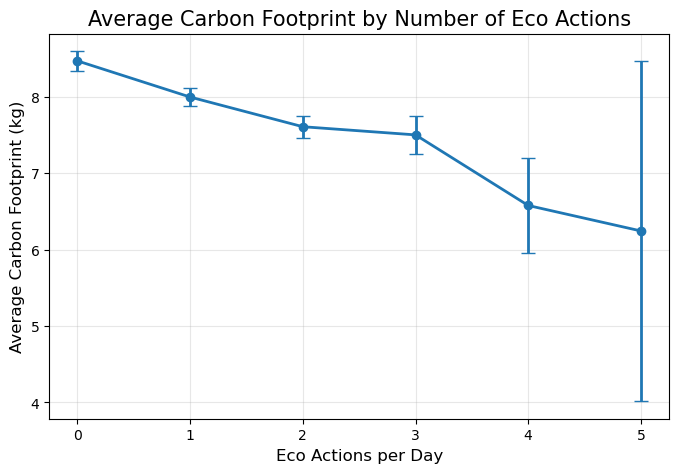

In [ ]:

stats = (df.groupby('eco_actions')['carbon_footprint_kg'].agg(['mean', 'std', 'count']))

stats['se'] = stats['std'] / np.sqrt(stats['count'])

print(stats)

plt.figure(figsize=(8,5))
plt.errorbar(stats.index,stats['mean'],yerr=stats['se'],marker='o',capsize=5,linewidth=2)

plt.xlabel('Eco Actions per Day',fontsize=12)
plt.ylabel('Average Carbon Footprint (kg)',fontsize=12)
plt.title('Average Carbon Footprint by Number of Eco Actions',fontsize=15)
plt.grid(alpha=0.3)

plt.show()

Error Bars Associated with Average Carbon based on Daily Eco-actions

This graph takes the graph above and showcases the standard error assocated with the values. As shown, after three daily eco-actions, the standard error increases drastically, due to the lack of user data on those with upwards of three actions. The dataset is heavily skewed towards those who do not contribute heavily to eco-actions, limiting the results avaialble. 

Error bars represent the variability in average footprint estimates, smaller bars indicating a greater confidence in the mean, while larger bars suggest smaller sample sizes (observed: half a percent of users at 5 eeco-actions) or higher variability.

In [ ]:
df['eco_count'] = df['eco_actions'].value_counts().sort_index()
df['eco_percent'] = df['eco_count']/len(df)*100
df_eco = df[['eco_count','eco_percent']]

print(df_eco.head(6))

   eco_count  eco_percent
0      424.0    30.285714
1      522.0    37.285714
2      321.0    22.928571
3       99.0     7.071429
4       29.0     2.071429
5        5.0     0.357143


In [ ]:
df['renewable_usage_pct'].value_counts().sort_index()

renewable_usage_pct
0      510
25     348
50     270
75     207
100     65
Name: count, dtype: int64

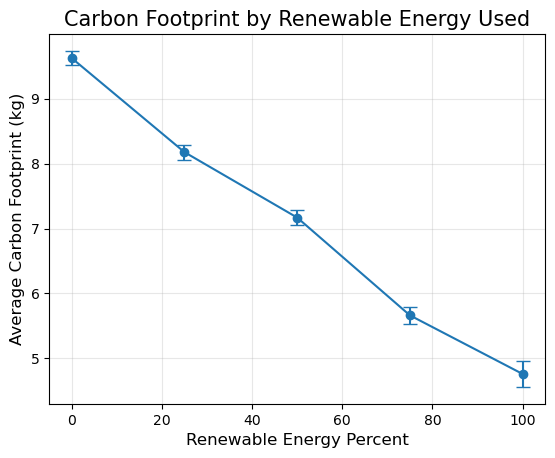

In [ ]:
stats = (df.groupby('renewable_usage_pct')['carbon_footprint_kg'].agg(['mean','std','count']))

stats['se'] = stats['std']/np.sqrt(stats['count'])

plt.errorbar(stats.index,stats['mean'],yerr=stats['se'],marker='o',capsize=5)
plt.title('Carbon Footprint by Renewable Energy Used',fontsize=15)
plt.ylabel('Average Carbon Footprint (kg)',fontsize=12)
plt.xlabel('Renewable Energy Percent',fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Carbon Footprint based on Renewable Energy Usage with Standard Error Bars

**Why this matters:** An increase in renewable energy usage is associated with a lower average carbon footprint. Standard error remains very small throughout each increment in renewable energy.


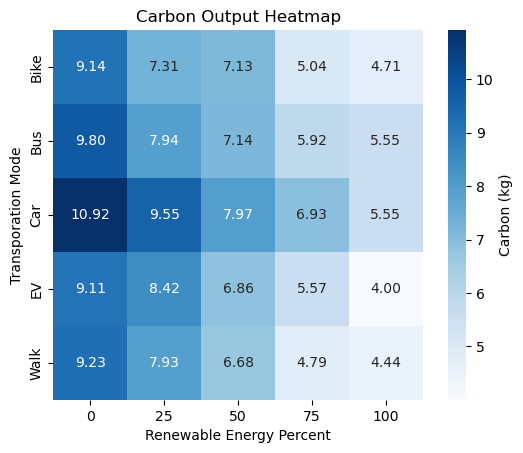

In [ ]:
pivot = df.pivot_table(values='carbon_footprint_kg',index='transport_mode',columns='renewable_usage_pct',aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='Blues', fmt='.2f', square=True, cbar_kws={'label': 'Carbon (kg)'})

plt.title('Carbon Output Heatmap', fontsize=12)
plt.xlabel('Renewable Energy Percent', fontsize=10)
plt.ylabel('Transporation Mode', fontsize=10)
plt.show()


Carbon Output based on Transportation Mode and Renewable Energy Used

This graph showcases the output of carbon when looking at users transportation and renewable energy usage. As the correlations shows, renewable energy is a great factor to mitigate carbon impact, with users 50% and above producing much less carbon than those who use fewer than 50% renewable. Additionally, regardless of tansportation method, greateer the renewable usage corresponds with lower emission averages.

Exploratory Data Analysis Summary

Major Findings:

Transportation choices were among the strongest contributor to carbon footprint.
A larger renewable energy adoption corresponded with lower emissions.
Increasig daily eco-actions was associated with valuable reductions in average carbon footprint.
Many behavioral variables showed moderate correlations, indicating that value can be obtained from using them in predictive modeling. 

These findings indicate that there is merit to using feature selection and predictive modeling in the next section.